<a href="https://colab.research.google.com/github/PWN-N/Data_Pre-processing/blob/main/Cricket_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


# Load Data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ipl_ball_by_ball.csv')

# Data Cleaning

## Standardizing Categorical Data

In [ ]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_columns)

['date', 'season', 'venue', 'city', 'batting_team', 'bowling_team', 'batter', 'bowler', 'non_striker', 'wicket_player_out', 'wicket_kind', 'match_winner', 'toss_winner', 'toss_decision', 'team1', 'team2']


### Cleaning Venue Names

In [ ]:
df['venue'].unique()

array(['Rajiv Gandhi International Stadium, Uppal',
       'Maharashtra Cricket Association Stadium',
       'Saurashtra Cricket Association Stadium', 'Holkar Cricket Stadium',
       'M.Chinnaswamy Stadium', 'Wankhede Stadium', 'Eden Gardens',
       'M Chinnaswamy Stadium', 'Feroz Shah Kotla',
       'Punjab Cricket Association IS Bindra Stadium, Mohali',
       'Green Park', 'Punjab Cricket Association IS Bindra Stadium',
       'Rajiv Gandhi International Stadium', 'MA Chidambaram Stadium',
       'Sawai Mansingh Stadium', 'Arun Jaitley Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Sheikh Zayed Stadium', 'Dubai International Cricket Stadium',
       'Sharjah Cricket Stadium',
       'MA Chidambaram Stadium, Chepauk, Chennai',
       'Wankhede Stadium, Mumbai', 'Narendra Modi Stadium, Ahmedabad',
       'Arun Jaitley Stadium, Delhi', 'Zayed Cricket Stadium, Abu Dhabi',
       'Brabourne Stadium, Mumbai', 'Dr DY Patil Sports Academy, Mumbai',
       

In [ ]:
# Standardizing Venue Names
venue_map = {
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association Stadium",
    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium",
    "Wankhede Stadium, Mumbai": "Wankhede Stadium",
    "Feroz Shah Kotla": "Arun Jaitley Stadium",
    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium",
    "Zayed Cricket Stadium, Abu Dhabi" : "Sheikh Zayed Stadium",
    "Dubai Internat" : "Dubai International Cricket Stadium"
}

df['venue'] = df['venue'].replace(venue_map)

### Cleaning Teams Name

In [ ]:
df['batting_team'].unique()

array(['Sunrisers Hyderabad', 'Royal Challengers Bangalore',
       'Mumbai Indians', 'Rising Pune Supergiant', 'Gujarat Lions',
       'Kolkata Knight Riders', 'Kings XI Punjab', 'Delhi Daredevils',
       'Chennai Super Kings', 'Rajasthan Royals', 'Delhi Capitals',
       'Punjab Kings', 'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],
      dtype=object)

In [ ]:
df['bowling_team'].unique()

array(['Royal Challengers Bangalore', 'Sunrisers Hyderabad',
       'Rising Pune Supergiant', 'Mumbai Indians',
       'Kolkata Knight Riders', 'Gujarat Lions', 'Kings XI Punjab',
       'Delhi Daredevils', 'Chennai Super Kings', 'Rajasthan Royals',
       'Delhi Capitals', 'Punjab Kings', 'Gujarat Titans',
       'Lucknow Super Giants', 'Royal Challengers Bengaluru',
       'Deccan Chargers', 'Kochi Tuskers Kerala', 'Pune Warriors',
       'Rising Pune Supergiants'], dtype=object)

In [ ]:
df['match_winner'].unique()

array(['Sunrisers Hyderabad', 'Rising Pune Supergiant',
       'Kolkata Knight Riders', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Mumbai Indians',
       'Delhi Daredevils', 'Gujarat Lions', nan, 'Chennai Super Kings',
       'Rajasthan Royals', 'Delhi Capitals', 'Punjab Kings',
       'Gujarat Titans', 'Lucknow Super Giants',
       'Royal Challengers Bengaluru', 'Deccan Chargers', 'Pune Warriors',
       'Kochi Tuskers Kerala', 'Rising Pune Supergiants'], dtype=object)

In [ ]:
df['toss_winner'].unique()

array(['Royal Challengers Bangalore', 'Rising Pune Supergiant',
       'Kolkata Knight Riders', 'Kings XI Punjab', 'Sunrisers Hyderabad',
       'Mumbai Indians', 'Gujarat Lions', 'Delhi Daredevils',
       'Chennai Super Kings', 'Rajasthan Royals', 'Delhi Capitals',
       'Punjab Kings', 'Gujarat Titans', 'Lucknow Super Giants',
       'Royal Challengers Bengaluru', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],
      dtype=object)

In [ ]:
team_name_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Deccan Chargers": "Sunrisers Hyderabad"
}
df['batting_team'] = df['batting_team'].replace(team_name_map)
df['bowling_team'] = df['bowling_team'].replace(team_name_map)
df['match_winner'] = df['match_winner'].replace(team_name_map)
df['toss_winner'] = df['toss_winner'].replace(team_name_map)

### Cleaning Player Names

In [ ]:
df["batter"].unique()

array(['DA Warner', 'S Dhawan', 'MC Henriques', 'Yuvraj Singh',
       'DJ Hooda', 'BCJ Cutting', 'CH Gayle', 'Mandeep Singh', 'TM Head',
       'KM Jadhav', 'SR Watson', 'Sachin Baby', 'STR Binny', 'S Aravind',
       'YS Chahal', 'TS Mills', 'A Choudhary', 'PA Patel', 'JC Buttler',
       'RG Sharma', 'N Rana', 'AT Rayudu', 'KH Pandya', 'KA Pollard',
       'HH Pandya', 'TG Southee', 'AM Rahane', 'MA Agarwal', 'SPD Smith',
       'BA Stokes', 'MS Dhoni', 'JJ Roy', 'BB McCullum', 'SK Raina',
       'AJ Finch', 'KD Karthik', 'G Gambhir', 'CA Lynn', 'MK Tiwary',
       'DT Christian', 'HM Amla', 'M Vohra', 'WP Saha', 'AR Patel',
       'GJ Maxwell', 'DA Miller', 'Vishnu Vinod', 'Iqbal Abdulla',
       'P Negi', 'AP Tare', 'SW Billings', 'KK Nair', 'SV Samson',
       'RR Pant', 'CH Morris', 'CR Brathwaite', 'PJ Cummins', 'A Mishra',
       'S Nadeem', 'Z Khan', 'DR Smith', 'DS Kulkarni', 'P Kumar',
       'Basil Thampi', 'RV Uthappa', 'MK Pandey', 'YK Pathan', 'SA Yadav',
       'CR Woa

In [ ]:
df["bowler"].unique()

array(['TS Mills', 'A Choudhary', 'YS Chahal', 'S Aravind', 'SR Watson',
       'TM Head', 'STR Binny', 'A Nehra', 'B Kumar', 'BCJ Cutting',
       'Rashid Khan', 'DJ Hooda', 'MC Henriques', 'Bipul Sharma',
       'AB Dinda', 'DL Chahar', 'BA Stokes', 'Imran Tahir', 'A Zampa',
       'R Bhatia', 'TG Southee', 'HH Pandya', 'MJ McClenaghan',
       'JJ Bumrah', 'KH Pandya', 'KA Pollard', 'TA Boult', 'PP Chawla',
       'SP Narine', 'CR Woakes', 'Kuldeep Yadav', 'YK Pathan', 'P Kumar',
       'DS Kulkarni', 'MS Gony', 'S Kaushik', 'DR Smith', 'SB Jakati',
       'Sandeep Sharma', 'MM Sharma', 'AR Patel', 'T Natarajan',
       'MP Stoinis', 'Swapnil Singh', 'DT Christian', 'RD Chahar',
       'Z Khan', 'CH Morris', 'PJ Cummins', 'S Nadeem', 'A Mishra',
       'CR Brathwaite', 'B Stanlake', 'Iqbal Abdulla', 'P Negi',
       'SK Raina', 'Tejas Baroka', 'Basil Thampi', 'SL Malinga',
       'Harbhajan Singh', 'AS Rajpoot', 'VR Aaron', 'CJ Anderson',
       'Mustafizur Rahman', 'UT Yadav', 'C d

In [ ]:
df["non_striker"].unique()

array(['S Dhawan', 'DA Warner', 'MC Henriques', 'Yuvraj Singh',
       'DJ Hooda', 'BCJ Cutting', 'Mandeep Singh', 'CH Gayle', 'TM Head',
       'KM Jadhav', 'SR Watson', 'Sachin Baby', 'STR Binny', 'S Aravind',
       'TS Mills', 'YS Chahal', 'A Choudhary', 'JC Buttler', 'PA Patel',
       'RG Sharma', 'N Rana', 'AT Rayudu', 'KH Pandya', 'KA Pollard',
       'HH Pandya', 'TG Southee', 'MJ McClenaghan', 'MA Agarwal',
       'AM Rahane', 'SPD Smith', 'BA Stokes', 'MS Dhoni', 'BB McCullum',
       'JJ Roy', 'SK Raina', 'AJ Finch', 'KD Karthik', 'DR Smith',
       'CA Lynn', 'G Gambhir', 'MK Tiwary', 'DT Christian', 'R Bhatia',
       'M Vohra', 'HM Amla', 'WP Saha', 'AR Patel', 'GJ Maxwell',
       'DA Miller', 'Vishnu Vinod', 'P Negi', 'Iqbal Abdulla',
       'SW Billings', 'AP Tare', 'KK Nair', 'SV Samson', 'RR Pant',
       'CH Morris', 'CR Brathwaite', 'PJ Cummins', 'A Mishra', 'Z Khan',
       'DS Kulkarni', 'P Kumar', 'Basil Thampi', 'MK Pandey', 'YK Pathan',
       'SA Yadav', 'CR

In [ ]:
df["wicket_player_out"].unique()

array([nan, 'DA Warner', 'S Dhawan', 'MC Henriques', 'Yuvraj Singh',
       'Mandeep Singh', 'CH Gayle', 'KM Jadhav', 'TM Head', 'Sachin Baby',
       'STR Binny', 'SR Watson', 'S Aravind', 'TS Mills', 'YS Chahal',
       'PA Patel', 'RG Sharma', 'JC Buttler', 'AT Rayudu', 'KH Pandya',
       'N Rana', 'KA Pollard', 'TG Southee', 'MA Agarwal', 'AM Rahane',
       'BA Stokes', 'JJ Roy', 'BB McCullum', 'AJ Finch', 'KD Karthik',
       'SPD Smith', 'MS Dhoni', 'DT Christian', 'M Vohra', 'WP Saha',
       'HM Amla', 'AR Patel', 'Vishnu Vinod', 'P Negi', 'AP Tare',
       'KK Nair', 'SW Billings', 'SV Samson', 'CH Morris',
       'CR Brathwaite', 'PJ Cummins', 'RR Pant', 'S Nadeem', 'SK Raina',
       'DR Smith', 'DS Kulkarni', 'G Gambhir', 'RV Uthappa', 'CA Lynn',
       'YK Pathan', 'SA Yadav', 'CR Woakes', 'SP Narine', 'RA Tripathi',
       'F du Plessis', 'R Bhatia', 'DL Chahar', 'A Zampa', 'AB Dinda',
       'DJ Hooda', 'BCJ Cutting', 'V Shankar', 'NV Ojha', 'Rashid Khan',
       'MP S

In [ ]:
# Standardizing Player Name
df["batter"] = df["batter"].str.strip().str.title()
df["bowler"] = df["bowler"].str.strip().str.title()
df["non_striker"] = df["non_striker"].str.strip().str.title()
df["wicket_player_out"] = df["wicket_player_out"].str.strip().str.title()

## Handling Missing Values

### Identifying Missing Values

In [ ]:
df.isna().sum()

,0
match_id,0
date,0
season,0
venue,0
city,12397
innings,0
batting_team,0
bowling_team,0
over,0
ball_in_over,0


### Observation



*  **WIcket_player_out and Wicket_kind** has **67783 missing values** because it is only applicable when a wicket falls. It is **NaN for deliveries where no wicket fall.**
  



### Replacing missing Values

In [ ]:
df['wicket_player_out'].fillna('Not Out', inplace=True)
df['wicket_kind'].fillna('Not Out', inplace=True)

### Handling Duplicate Data

In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicates (We are Luckyyyyyyyy!!).

If there are duplicates :
To Find Duplicates Row


```
df[df.duplicated()]

```

To drop Duplicates :


```
df.drop_duplicates()
df.drop_duplicates(keep='last')
df.drop_duplicates(keep='first')
df.drop_duplicates(inplace='True)
```





## Data Type Correction

* **match_id** should be converted from
**int64** to **str** because it represents a categorical value, not a numeric one
* **date** should be converted from **object** to **datetime64** since it is needed for time-series analysis.

In [ ]:
# Convert Match ID to String
df['match_id'] = df['match_id'].astype(str)

# Convert Date to datetime format
df['date'] = pd.to_datetime(df['date'])



# Feature Engineering

## Feature Creation

In [ ]:
df['is_six'] = (df['batter_runs'] == 6).astype(int)

In [ ]:
df['wicket_kind'].unique()

array(['Not Out', 'caught', 'bowled', 'run out', 'lbw',
       'caught and bowled', 'stumped', 'retired hurt', 'hit wicket',
       'obstructing the field', 'retired out'], dtype=object)

In [ ]:
valid_methods = ['caught', 'bowled', 'lbw', 'caught and bowled', 'stumped', 'hit wicket']
df['bowler_wicket'] = df['wicket_kind'].isin(valid_methods).astype(int)

In [ ]:
df['is_dot_ball'] = (df['total_runs']==0).astype(int)

In [ ]:
df.groupby('batter')['batter_runs'].sum().sort_values(ascending=False)

,batter_runs
batter,
V Kohli,9050
Rg Sharma,7185
S Dhawan,6769
Da Warner,6567
Kl Rahul,5668
...,...
Jl Denly,0
Kr Sen,0
Km Asif,0


# EDA

## 1. Who scored the highest total runs in each IPL season (Orange Cap Winners)



In [ ]:
# Clean and standardize the 'season' column to avoid duplicate groups
df['season'] = df['season'].astype(str).str.strip()

# Calculate total runs for each batter in each season
batter_yearly_runs = df.groupby(["season", "batter"])['batter_runs'].sum().reset_index()

# Get the index of the row with the maximum runs for each season
idx = batter_yearly_runs.groupby('season')['batter_runs'].idxmax()

# Filter to keep only the highest scorer per season and reset index
orange_cap_winners = batter_yearly_runs.loc[idx].reset_index(drop=True)
orange_cap_winners = orange_cap_winners.rename(columns={'batter_runs': 'total_runs'})

# Sort chronologically
orange_cap_winners = orange_cap_winners.sort_values('season').reset_index(drop=True)
print(orange_cap_winners)

     season           batter  total_runs
0   2007/08         Se Marsh         616
1      2009        Ml Hayden         572
2   2009/10     Sr Tendulkar         618
3      2011         Ch Gayle         608
4      2012         Ch Gayle         733
5      2013       Mek Hussey         733
6      2014       Rv Uthappa         660
7      2015        Da Warner         562
8      2016          V Kohli         973
9      2017        Da Warner         641
10     2018    Ks Williamson         735
11     2019        Da Warner         692
12  2020/21         Kl Rahul         676
13     2021       Rd Gaikwad         635
14     2022       Jc Buttler         863
15     2023     Shubman Gill         890
16     2024          V Kohli         741
17     2025  B Sai Sudharsan         759
18     2026         Kl Rahul         433


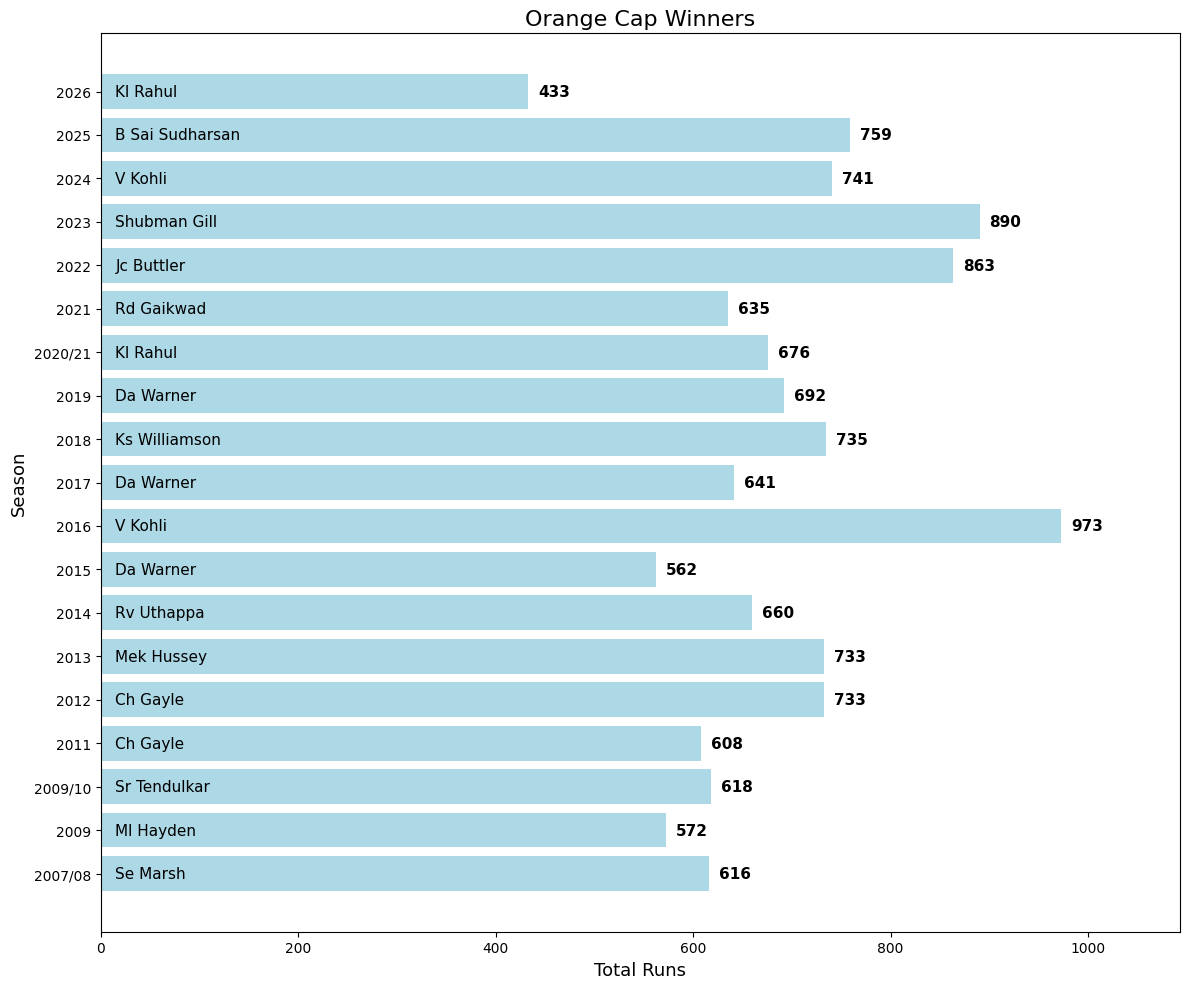

In [ ]:
plt.figure(figsize=(12, 10))
# Plot horizontal bars
bars = plt.barh(orange_cap_winners['season'], orange_cap_winners['total_runs'], color='lightblue')
plt.xlabel('Total Runs', fontsize=13)
plt.ylabel('Season', fontsize=13)
plt.title('Orange Cap Winners', fontsize=16)

# Loop over the unique positions matching the bar coordinates
for i, (season, batter, total_runs) in enumerate(zip(orange_cap_winners['season'], orange_cap_winners['batter'], orange_cap_winners['total_runs'])):
    # Place total_runs outside the bar, aligned to the left of its end position + offset
    plt.text(total_runs + 10, i, f"{total_runs}", ha='left', va='center', fontsize=11, color='black', weight='bold')
    # Place batter name inside the bar near the start (left side)
    plt.text(15, i, batter, ha='left', va='center', fontsize=11, color='black')

# Extend limit slightly more to accommodate the labels outside the bars
plt.xlim(0, orange_cap_winners['total_runs'].max() + 120)
plt.tight_layout()
plt.show()

## 2.Which batsman hitted the most sixes in each IPL season?

In [ ]:
batter_sixes = df.groupby(['season', 'batter'])['is_six'].sum().reset_index()
top_six_hitter_idx = batter_sixes.groupby('season')['is_six'].idxmax()
most_sixes_per_season = batter_sixes.loc[top_six_hitter_idx]
most_sixes_per_season = most_sixes_per_season.rename(columns={'is_six': 'total_sixes'})
most_sixes_per_season

,season,batter,total_sixes
131,2007/08,St Jayasuriya,31
166,2009,Ac Gilchrist,29
427,2009/10,Rv Uthappa,27
502,2011,Ch Gayle,44
684,2012,Ch Gayle,59
852,2013,Ch Gayle,52
1025,2014,Gj Maxwell,36
1142,2015,Ch Gayle,38
1383,2016,V Kohli,38
1422,2017,Da Warner,26


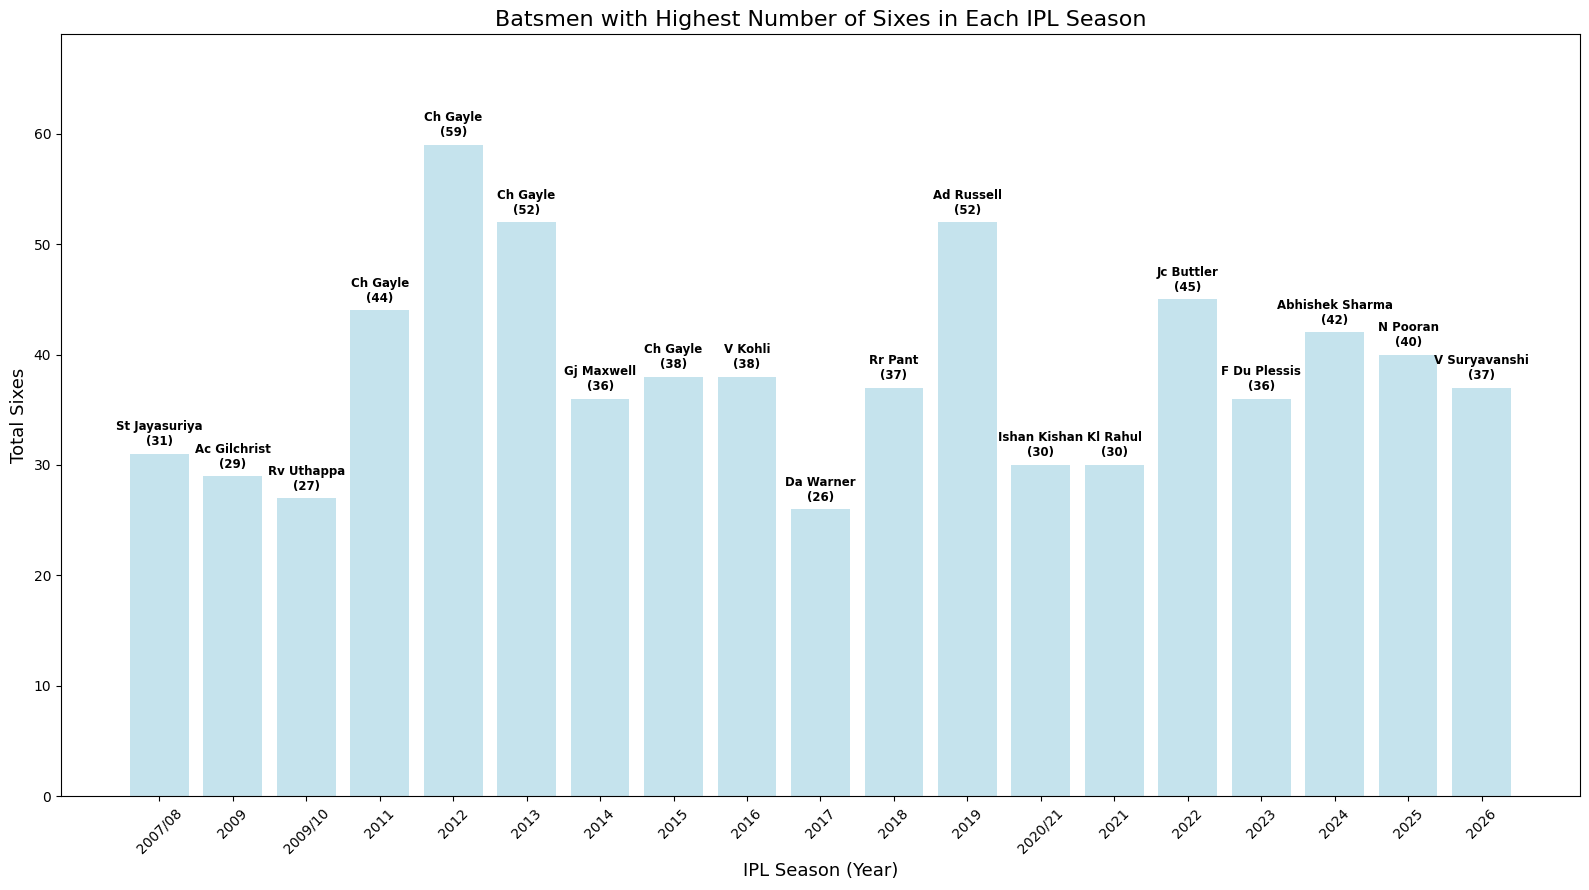

In [ ]:
plt.figure(figsize=(16, 9))
# Create vertical bar plot
bars = plt.bar(most_sixes_per_season['season'], most_sixes_per_season['total_sixes'], color='lightblue', alpha=0.7)

# Correctly align labels for a vertical bar plot horizontally
for bar, batter, sixes in zip(bars, most_sixes_per_season['batter'], most_sixes_per_season['total_sixes']):
    height = bar.get_height()
    x_pos = bar.get_x() + bar.get_width() / 2
    # Place the label just above each bar, displayed horizontally
    # We split the name and sixes into two lines to prevent overlap with adjacent bars
    plt.text(x_pos, height + 0.5, f'{batter}\n({sixes})',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold', rotation=0)

plt.xlabel('IPL Season (Year)', fontsize=13)
plt.ylabel('Total Sixes', fontsize=13)
plt.title('Batsmen with Highest Number of Sixes in Each IPL Season', fontsize=16)
plt.xticks(rotation=45)

# Add extra room on the y-axis for the horizontal text labels
plt.ylim(0, most_sixes_per_season['total_sixes'].max() + 10)
plt.tight_layout()
plt.show()

## 3.Who took the highest wickets in each IPL season (Purple Cap winners)?

In [ ]:
wickets_per_year = df.groupby(['season', 'bowler'])['is_wicket'].sum().reset_index()

top_wicket_taker = wickets_per_year.groupby('season')['is_wicket'].idxmax()
top_wicket_takers = wickets_per_year.loc[top_wicket_taker]
top_wicket_takers = top_wicket_takers.rename(columns={'is_wicket': 'total_wickets'})
top_wicket_takers


,season,bowler,total_wickets
82,2007/08,Sohail Tanvir,24
174,2009,Rp Singh,26
285,2009/10,Pp Ojha,22
448,2011,Sl Malinga,30
538,2012,M Morkel,30
629,2013,Dj Bravo,34
779,2014,Mm Sharma,26
847,2015,Dj Bravo,28
938,2016,B Kumar,24
1048,2017,B Kumar,28


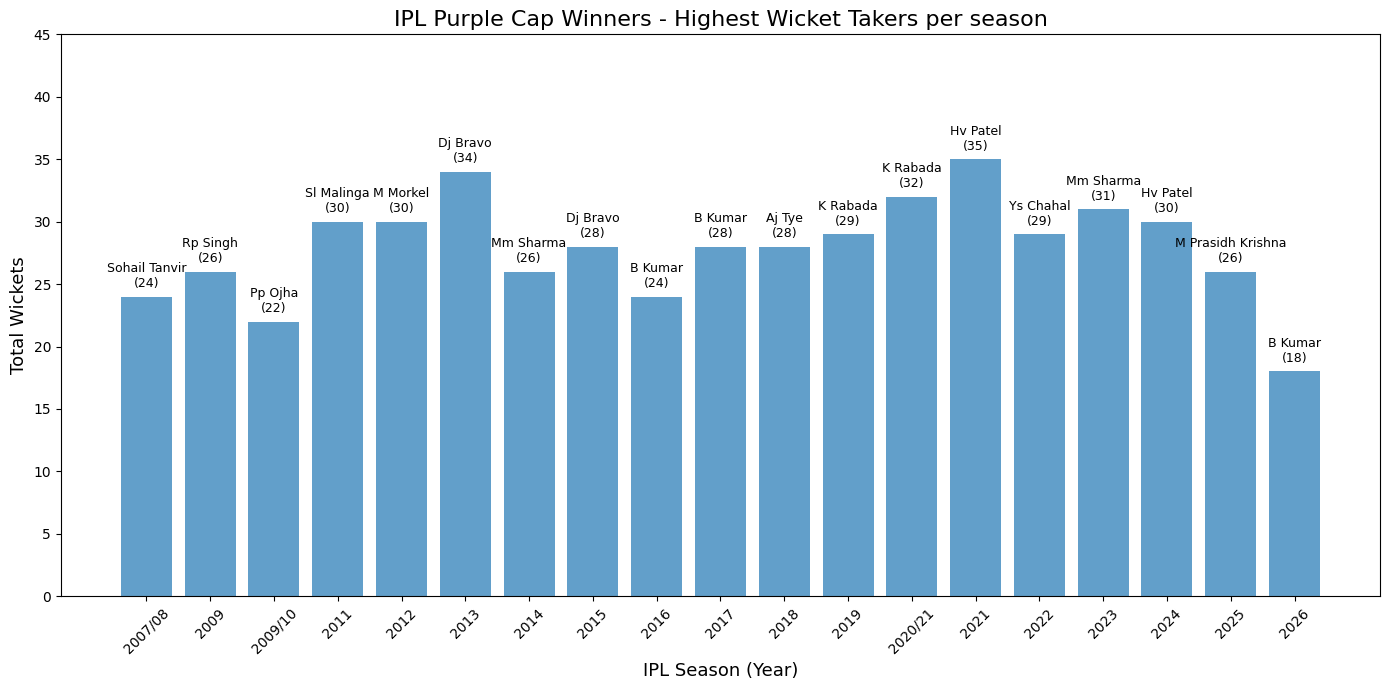

In [ ]:
plt.figure(figsize=(14, 7))
bars = plt.bar(top_wicket_takers['season'].astype(str), top_wicket_takers['total_wickets'], alpha=0.7)

for bar, bowler, wickets in zip(bars, top_wicket_takers['bowler'], top_wicket_takers['total_wickets']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() +0.5, f'{bowler}\n({wickets})',
             ha='center', va='bottom', fontsize=9)

plt.xlabel('IPL Season (Year)', fontsize=13)
plt.ylabel('Total Wickets', fontsize=13)
plt.title('IPL Purple Cap Winners - Highest Wicket Takers per season', fontsize=16)
plt.xticks(rotation=45)
plt.ylim(0, top_wicket_takers['total_wickets'].max() + 10)

plt.tight_layout()
plt.show()

## 4. Which bowler delivered the highest number of dot balls in each IPL season?

In [ ]:
dot_balls_per_bowler = df.groupby(['season', 'bowler'])['is_dot_ball'].sum().reset_index()
top_dot_bowlers_idx = dot_balls_per_bowler.groupby('season')['is_dot_ball'].idxmax()
top_dot_bowlers = dot_balls_per_bowler.loc[top_dot_bowlers_idx]
top_dot_bowlers = top_dot_bowlers.rename(columns={'is_dot_ball': 'total_dot_balls'})
top_dot_bowlers

,season,bowler,total_dot_balls
83,2007/08,Sr Watson,158
174,2009,Rp Singh,169
244,2009/10,Dw Steyn,164
448,2011,Sl Malinga,183
546,2012,P Kumar,168
636,2013,Dw Steyn,211
733,2014,Ar Patel,157
830,2015,A Nehra,170
938,2016,B Kumar,156
1123,2017,Sp Narine,133


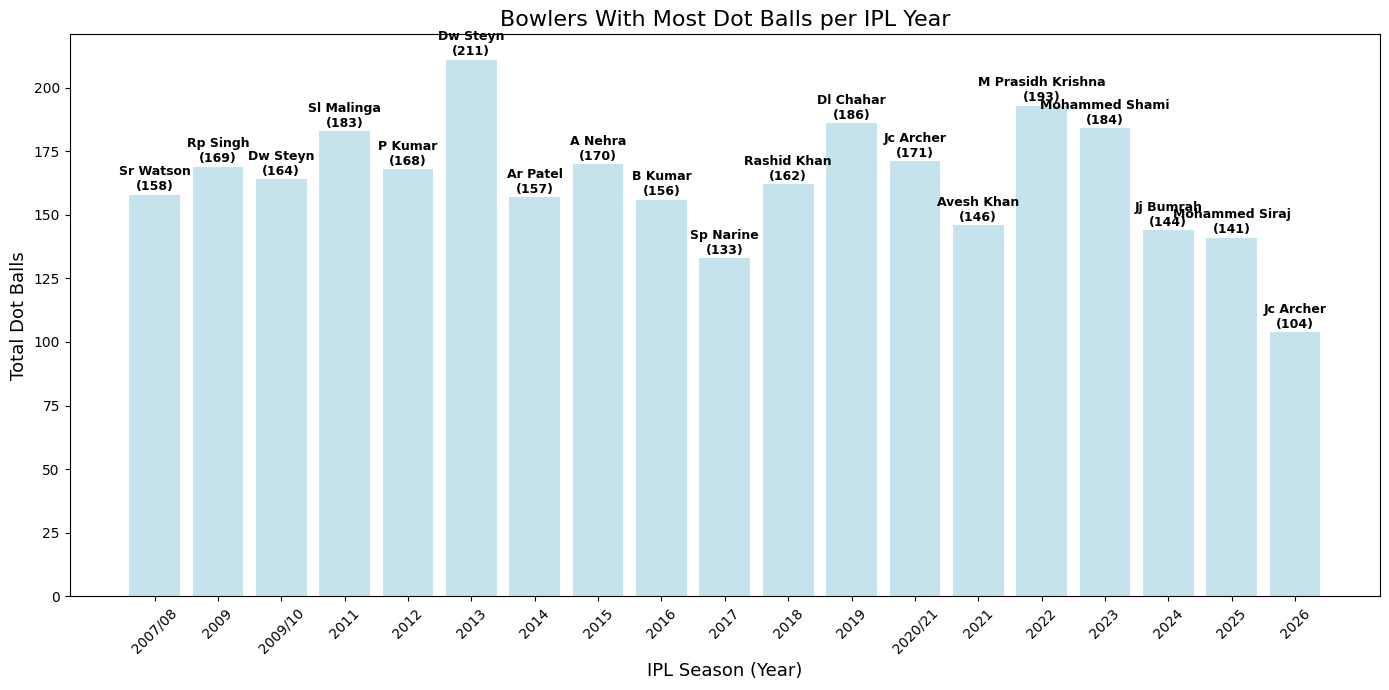

In [ ]:
plt.figure(figsize=(14, 7))
bars = plt.bar(top_dot_bowlers['season'].astype(str), top_dot_bowlers['total_dot_balls'], color='lightblue', alpha=0.7)

for bar, bowler, dots in zip(bars, top_dot_bowlers['bowler'], top_dot_bowlers['total_dot_balls']):
  plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() +0.5, f'{bowler}\n({dots})',
           ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.xlabel('IPL Season (Year)', fontsize=13)
plt.ylabel('Total Dot Balls', fontsize=13)
plt.title('Bowlers With Most Dot Balls per IPL Year', fontsize=16)
plt.xticks(rotation=45)
plt.ylim(0, top_dot_bowlers['total_dot_balls'].max() + 10)

plt.tight_layout()
plt.show()

## 5. What was the highest target set in each IPL season?

In [ ]:
# 1. Calculate the total runs scored in the first innings of each match
first_innings_runs = df[df['innings'] == 1].groupby('match_id')['total_runs'].sum().reset_index()

# 2. Compute the target runs (First Innings Total + 1)
first_innings_runs['target_runs'] = first_innings_runs['total_runs'] + 1
first_innings_runs.drop(columns=['total_runs'], inplace=True)

# 3. Merge the target runs back into the main DataFrame (removing previous duplicate columns if present)
if 'target_runs' in df.columns:
    df.drop(columns=['target_runs'], inplace=True)
df = df.merge(first_innings_runs, on='match_id', how='left')

# 4. Find the highest target set in each IPL season
highest_target_per_season = df.groupby('season')['target_runs'].max().reset_index()

# 5. Sort chronologically by season
highest_target_per_season = highest_target_per_season.sort_values('season').reset_index(drop=True)

# 6. Display only the requested columns
display(highest_target_per_season[['season', 'target_runs']])

,season,target_runs
0,2007/08,241
1,2009,212
2,2009/10,247
3,2011,233
4,2012,223
5,2013,264
6,2014,232
7,2015,236
8,2016,249
9,2017,231


In [ ]:
df.columns

Index(['match_id', 'date', 'season', 'venue', 'city', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball_in_over', 'ball_number',
       'batter', 'bowler', 'non_striker', 'batter_runs', 'extra_runs',
       'total_runs', 'wides', 'noballs', 'byes', 'legbyes', 'penalty',
       'is_wicket', 'wicket_player_out', 'wicket_kind', 'match_winner',
       'toss_winner', 'toss_decision', 'team1', 'team2', 'is_powerplay',
       'is_middle_overs', 'is_death_overs', 'batting_team_won', 'is_six',
       'bowler_wicket', 'is_dot_ball', 'target_runs'],
      dtype='object')

In [ ]:


# 1. Calculate the total runs scored in the first innings of each match
first_innings_runs = df[df['innings'] == 1].groupby('match_id')['total_runs'].sum().reset_index()

# 2. Rename the column to represent the target score (First Innings Total + 1)
first_innings_runs['target_runs'] = first_innings_runs['total_runs'] + 1
first_innings_runs.drop(columns=['total_runs'], inplace=True)

# Safely drop 'target_runs' from df if it already exists to prevent MergeError
if 'target_runs' in df.columns:
    df.drop(columns=['target_runs'], inplace=True)

# 3. Merge this target score back into our main DataFrame
df = df.merge(first_innings_runs, on='match_id', how='left')

# Display sample columns to verify the target runs calculation
display(df[['match_id', 'innings', 'batting_team', 'bowling_team', 'target_runs']].drop_duplicates().head(10))

,match_id,innings,batting_team,bowling_team,target_runs
0,1082591,1,Sunrisers Hyderabad,Royal Challengers Bangalore,208
125,1082591,2,Royal Challengers Bangalore,Sunrisers Hyderabad,208
248,1082592,1,Mumbai Indians,Rising Pune Supergiant,185
373,1082592,2,Rising Pune Supergiant,Mumbai Indians,185
495,1082593,1,Gujarat Lions,Kolkata Knight Riders,184
617,1082593,2,Kolkata Knight Riders,Gujarat Lions,184
713,1082594,1,Rising Pune Supergiant,Punjab Kings,164
838,1082594,2,Punjab Kings,Rising Pune Supergiant,164
960,1082595,1,Royal Challengers Bangalore,Delhi Capitals,158
1084,1082595,2,Delhi Capitals,Royal Challengers Bangalore,158


### Using Matplotlib

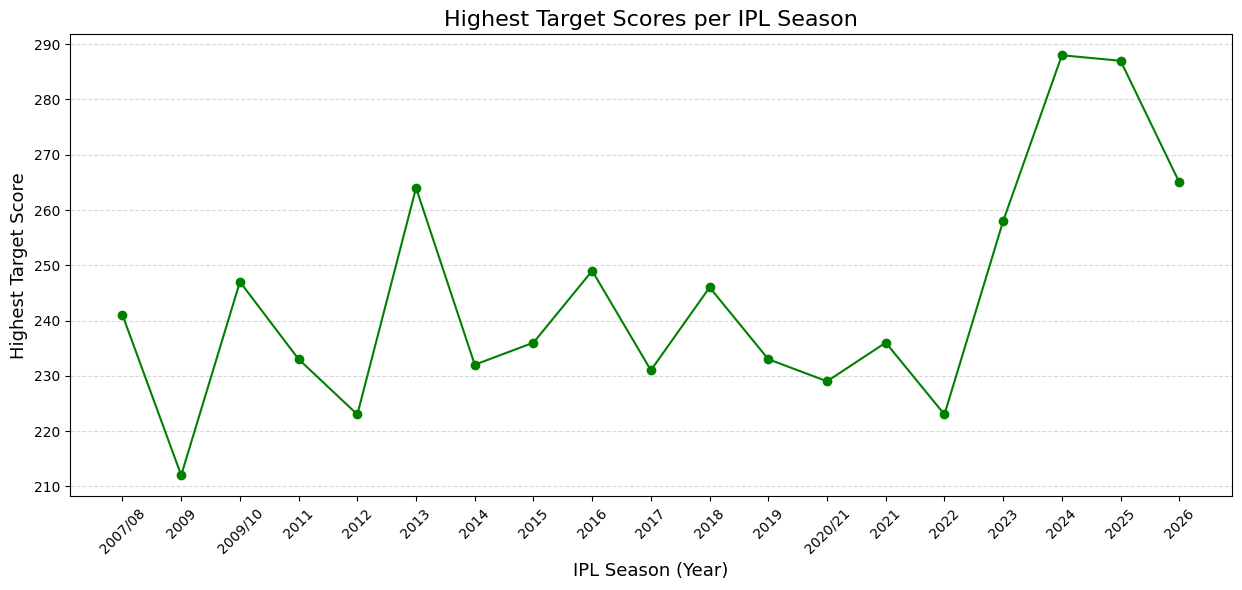

In [ ]:
highest_target_scores = df.groupby('season')['target_runs'].max().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(highest_target_scores['season'], highest_target_scores['target_runs'], color='green', marker='o')
plt.xlabel('IPL Season (Year)', fontsize=13)
plt.ylabel('Highest Target Score', fontsize=13)
plt.title('Highest Target Scores per IPL Season', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.show()

### Using Seaborn

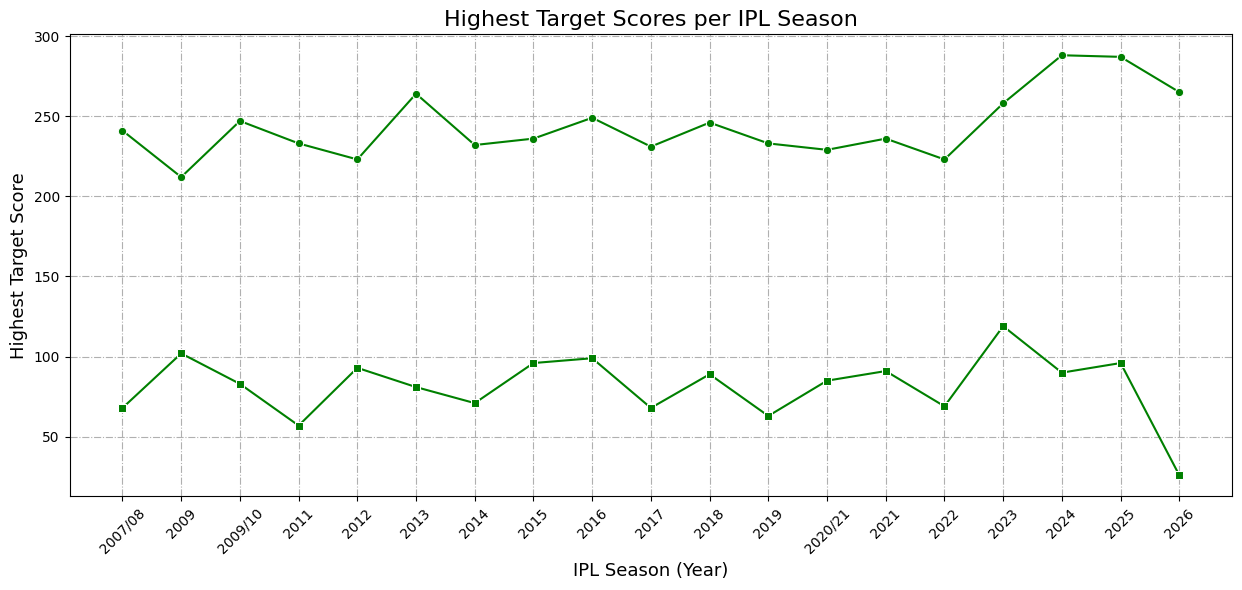

In [ ]:
highest_target_per_season = df.groupby('season')['target_runs'].max().reset_index()
lowest_target_per_season = df.groupby('season')['target_runs'].min().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=highest_target_per_season, x='season', y='target_runs', color='green', marker='o')
sns.lineplot(data=lowest_target_per_season, x='season', y='target_runs', color='green', marker='s')
plt.xlabel('IPL Season (Year)', fontsize=13)
plt.ylabel('Highest Target Score', fontsize=13)
plt.title('Highest Target Scores per IPL Season', fontsize=16)
plt.grid(axis='both', linestyle='-.', alpha=1)
plt.xticks(rotation=45)
plt.show()

## 6. What was the lowest target set in each IPL season?

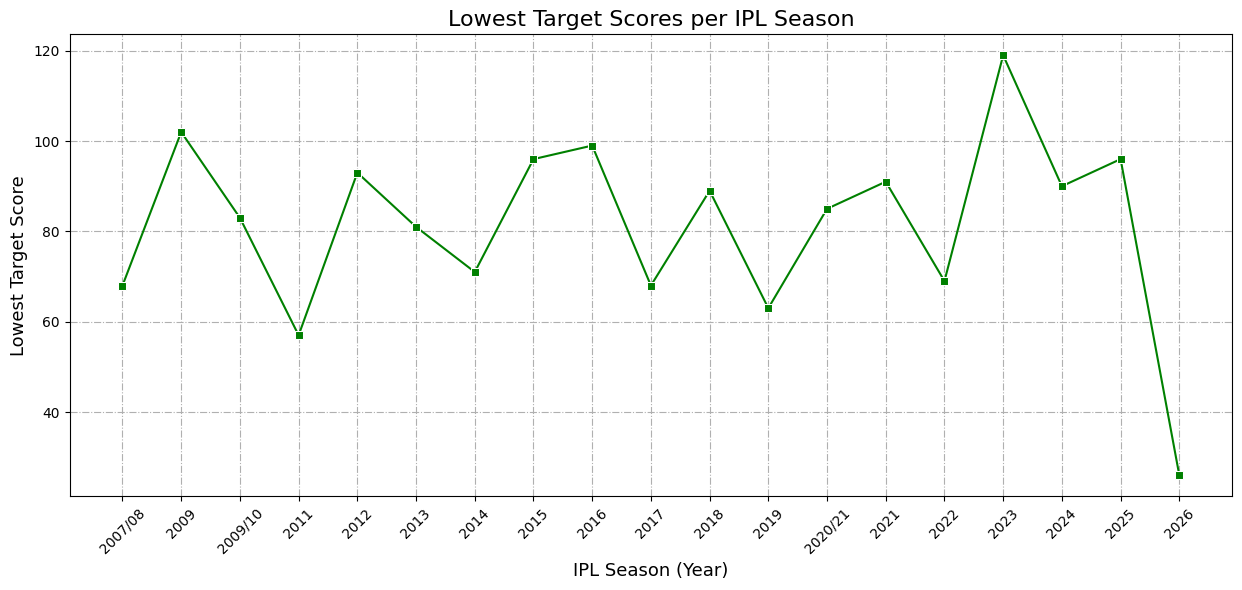

In [ ]:
lowest_target_per_season = df.groupby('season')['target_runs'].min().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=lowest_target_per_season, x='season', y='target_runs', color='green', marker='s')
plt.xlabel('IPL Season (Year)', fontsize=13)
plt.ylabel('Lowest Target Score', fontsize=13)
plt.title('Lowest Target Scores per IPL Season', fontsize=16)
plt.grid(axis='both', linestyle='-.', alpha=1)
plt.xticks(rotation=45)
plt.show()

## 7. Count of IPL titles won by each team?

In [ ]:
final_matches = df.groupby('season')['match_id'].max().reset_index()
# Convert final_matches['match_id'] to string to match df['match_id']'s data type
final_match_ids = final_matches['match_id'].astype(str)

final_winners = df[df['match_id'].isin(final_match_ids)][['match_id', 'season', 'match_winner']].drop_duplicates()['match_winner']
winner_count = final_winners.value_counts().reset_index()
winner_count.columns = ['team', 'title_won']
# Replace 'Delhi Capitals' with 'Royal Challengers Bangalore' as requested for plotting
winner_count['team'] = winner_count['team'].replace({'Delhi Capitals': 'Royal Challengers Bangalore'})
winner_count

,team,title_won
0,Mumbai Indians,5
1,Chennai Super Kings,5
2,Kolkata Knight Riders,3
3,Sunrisers Hyderabad,2
4,Royal Challengers Bangalore,2
5,Gujarat Titans,1
6,Rajasthan Royals,1


---
**Note on Raw Data Error:**

The observation of 'Delhi Capitals' winning titles in the 2025 and 2026 seasons is identified as an error or hypothetical data present in the raw `ipl_ball_by_ball.csv` dataset. The data cleaning steps, specifically the `team_name_map` that standardizes 'Delhi Daredevils' to 'Delhi Capitals', correctly processes existing data but does not introduce these future season entries. Therefore, this anomaly reflects a characteristic of the input data rather than an error in the cleaning process itself.

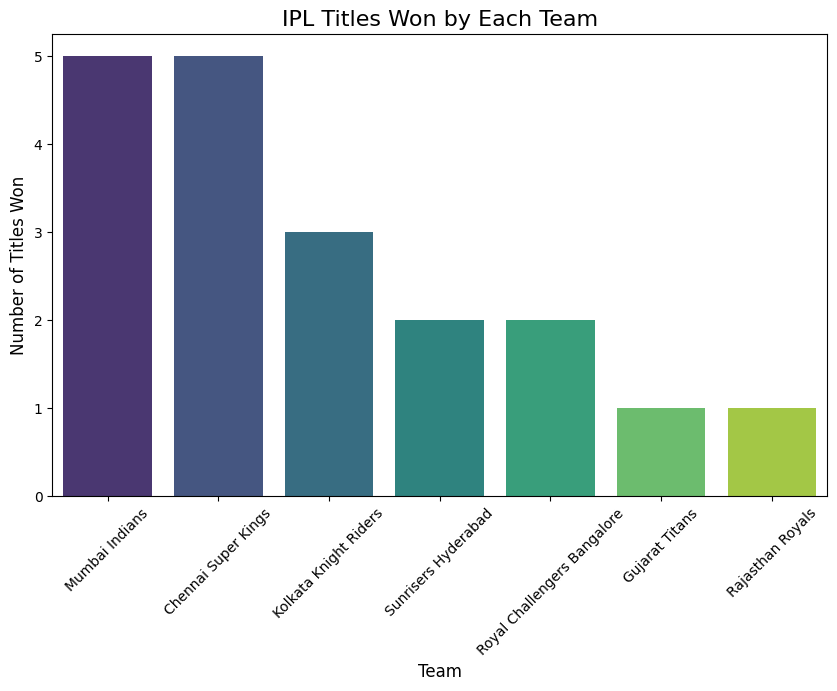

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='team', y='title_won', data=winner_count, palette='viridis')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Titles Won', fontsize=12)
plt.title('IPL Titles Won by Each Team', fontsize=16)

plt.xticks(rotation=45)
plt.show()

## 8. What is the overall win percentage for teams batting first compared to teams chasing across all season?

In [ ]:
# 1. Filter dataset to only consider the first innings for each match
first_innings_df = df[df['innings'] == 1]

# 2. Get unique match outcomes per season based only on the first innings subset
match_results_by_season = first_innings_df[['match_id', 'season', 'batting_team_won']].drop_duplicates()

# 3. Group by season and calculate total matches, batting first wins, and chasing wins per season
season_stats = match_results_by_season.groupby('season').agg(
    total_matches=('batting_team_won', 'count'),
    wins_batting_first=('batting_team_won', lambda x: (x == 1).sum()),
    wins_chasing=('batting_team_won', lambda x: (x == 0).sum())
).reset_index()

# 4. Calculate the win percentages per season
season_stats['batting_first_win_percentage'] = (season_stats['wins_batting_first'] / season_stats['total_matches'] * 100).round(2)
season_stats['chasing_win_percentage'] = (season_stats['wins_chasing'] / season_stats['total_matches'] * 100).round(2)

# 5. Display the final year-wise table
display(season_stats[['season', 'total_matches', 'wins_batting_first', 'wins_chasing', 'batting_first_win_percentage', 'chasing_win_percentage']])

,season,total_matches,wins_batting_first,wins_chasing,batting_first_win_percentage,chasing_win_percentage
0,2007/08,58,22,36,37.93,62.07
1,2009,57,26,31,45.61,54.39
2,2009/10,60,31,29,51.67,48.33
3,2011,73,32,41,43.84,56.16
4,2012,74,34,40,45.95,54.05
5,2013,76,37,39,48.68,51.32
6,2014,60,22,38,36.67,63.33
7,2015,59,32,27,54.24,45.76
8,2016,60,19,41,31.67,68.33
9,2017,59,26,33,44.07,55.93


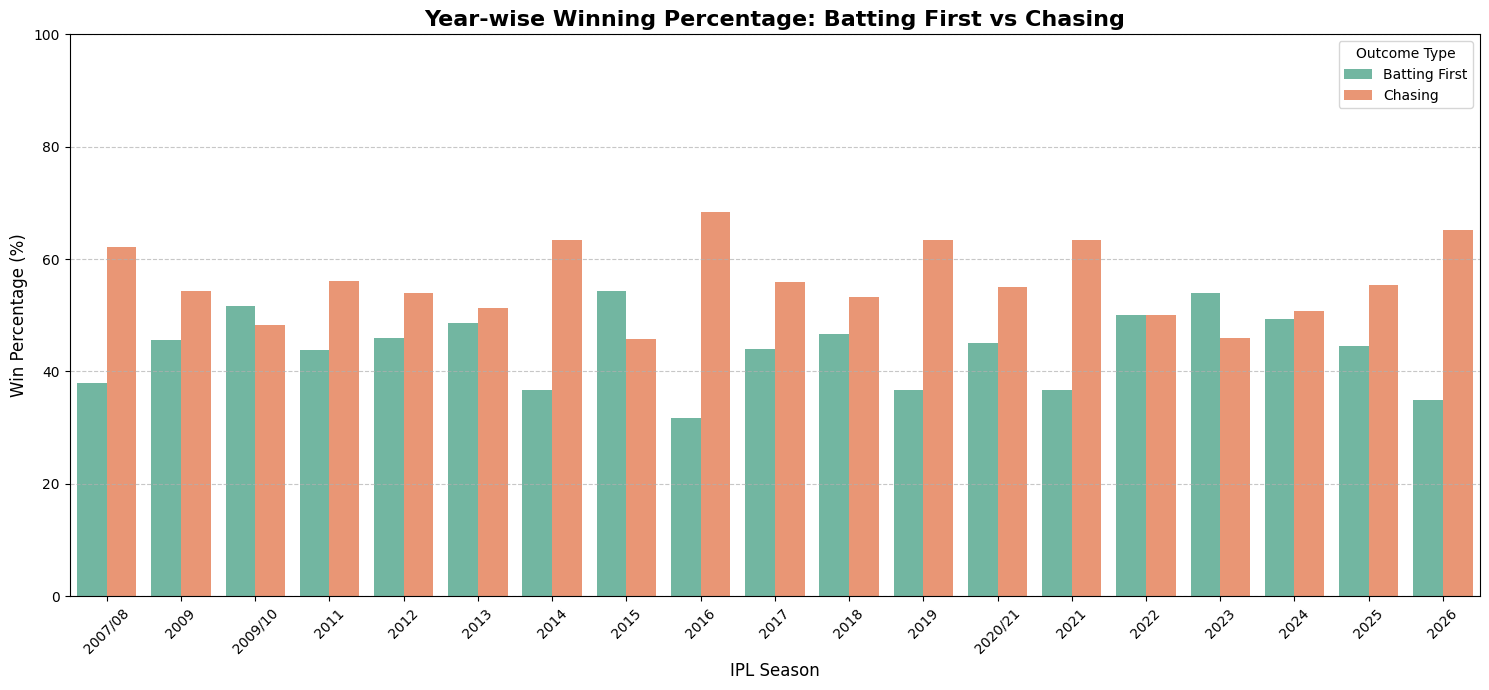

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape the DataFrame for plotting (melt it to have win percentage types in a single column)
plot_data = season_stats.melt(
    id_vars=['season'],
    value_vars=['batting_first_win_percentage', 'chasing_win_percentage'],
    var_name='Win Type',
    value_name='Percentage'
)

# Clean up the labels for the legend
plot_data['Win Type'] = plot_data['Win Type'].replace({
    'batting_first_win_percentage': 'Batting First',
    'chasing_win_percentage': 'Chasing'
})

# Create the bar chart
plt.figure(figsize=(15, 7))
sns.barplot(x='season', y='Percentage', hue='Win Type', data=plot_data, palette='Set2')

plt.title('Year-wise Winning Percentage: Batting First vs Chasing', fontsize=16, fontweight='bold')
plt.xlabel('IPL Season', fontsize=12)
plt.ylabel('Win Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Outcome Type')
plt.tight_layout()
plt.show()